# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [276]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_1490472/3290729079.py:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt


In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def process_autocorr(filename, V=30.450711**3, k_B=1.0, T =1.0):
    data = pd.read_csv(filename, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
    G_t = V / (k_B * T) *  (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                    V / (k_B * T) * (data['px_y'] + data['px_z'] + data['py_z']) / 30.0
    # replace negative values
    G_t = G_t.where(G_t >= 0, np.nan)
    data['G_t'] = G_t

    return data

def process_dyn_moduli(data, omega=np.logspace(-5, 3, 100), cutoff=1000):
    data.dropna(inplace=True)  # drop rows with NaN values
    
    time = data['time'].values
    prepped_G_t = data['G_t'][(time > 1) & (time < cutoff)].values
    prepped_time = time[(time > 1) & (time < cutoff)]

    
    _, Gp, Gpp = fourier_integral_moduli(prepped_time, prepped_G_t, omega)

    return Gp, Gpp

## Let's try to calculate autocorr ourselves, instead of multiple tau, just to verify it 

(if they're obviously different, we need to take a closer look)

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

As = [80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150]
cutoffs = [2000, 1450, 2000, 2000, 3500, 5200, 14000, 15000, 40000, 80000, 100000, 220000, 220000, 260000, 400000000]

V = 30.450711**3
k_B = 1.0
T  = 1.0

data = []

for i, A in enumerate(As):
    data.append(process_autocorr(f'data/autocorrelation/prodautocorr_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.dat', T=T, k_B=k_B, V=V))



In [279]:
# graph from Schmid paper with N=30 points extracted from their plot
data_schmid = pd.read_csv("data/comparison/g_t_n30.csv", names=['G_t', 'time'])
display(data_schmid.head())

,G_t,time
0,1.657352,0.469196
1,1.154304,0.674148
2,0.315360,3.851678
3,0.203903,7.859024
4,0.168334,10.626086


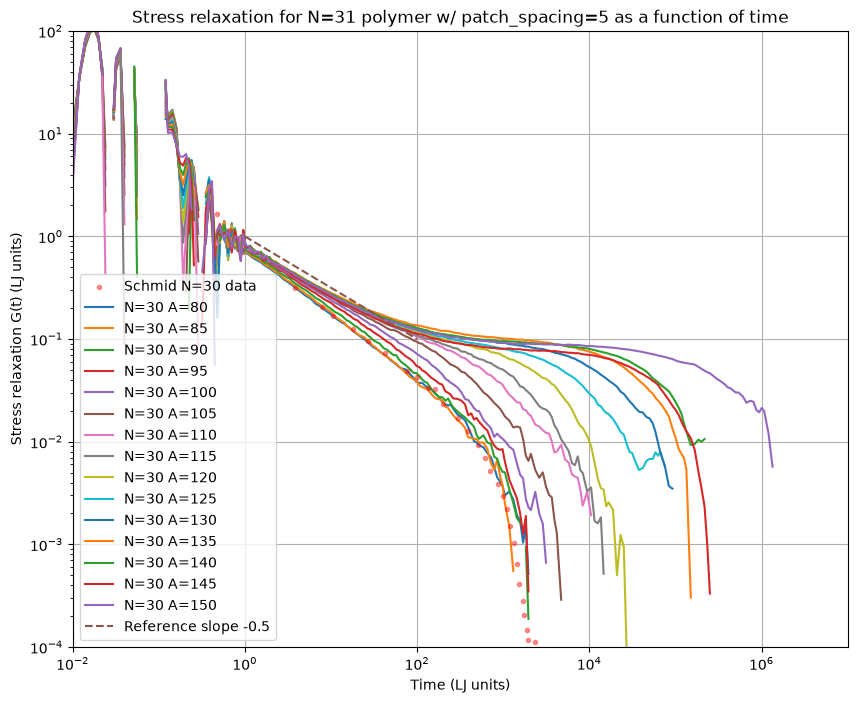

In [280]:
plt.figure(figsize=(10, 8))
plt.xscale('log')
plt.yscale('log')

# plt.loglog(data_multitau['time'], G_t_multitau , label='multitau autocorrelation')
# plt.loglog(data_multitau_no_langevin['time'], G_t_multitau_no_langevin , label='multitau autocorrelation (no Langevin)')
plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)

for i, A in enumerate(As):
    plt.loglog(data[i]['time'][data[i]['time'] < cutoffs[i]], data[i]['G_t'][data[i]['time'] < cutoffs[i]], label=f'N=30 A={A}')

plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e7])
plt.ylim([1e-4,1e2])
plt.grid()
plt.title('Stress relaxation for N=31 polymer w/ patch_spacing=5 as a function of time')
plt.legend()
plt.show()

In [281]:
def trap_integral_dynamic_moduli(omega, G_t, t):
    G_p = np.zeros_like(omega)
    G_pp = np.zeros_like(omega)
    for i, w in enumerate(omega):
        integral = np.trapezoid(G_t * np.exp(-1j * w * t), t)
        G_p[i] = -w * integral.imag
        G_pp[i] = w * integral.real
    return G_p, G_pp

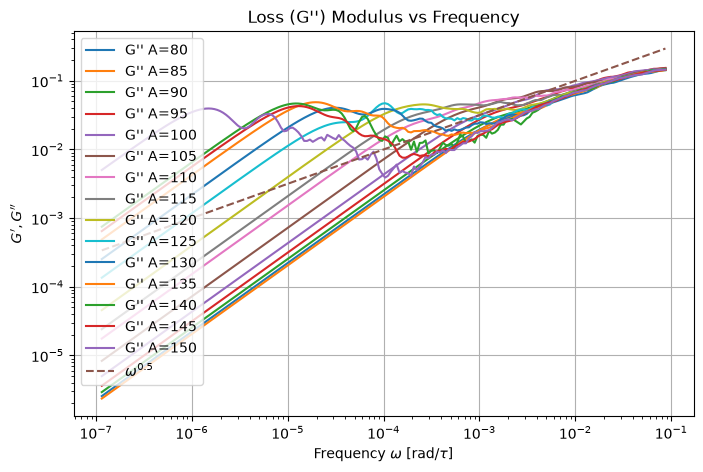

In [ ]:
omega = np.logspace(-7, -1, 200)
averaging_window = 9

Gp_list = []
Gpp_list = []
for i, A in enumerate(As):
    # Gp, Gpp = trap_integral_dynamic_moduli(G_t=data[i]['G_t'][(data[i]['time'] > 1) & (data[i]['time'] < cutoffs[i])], omega=omega, t=data[i]['time'].values[(data[i]['time'] > 1) & (data[i]['time'] < cutoffs[i])])
    # print(len(np.isnan(Gp)), len(np.isnan(Gpp)))
    Gp, Gpp = process_dyn_moduli(data[i], omega=omega, cutoff=cutoffs[i])
    Gp = np.convolve(Gp, np.ones(averaging_window)/averaging_window, mode='valid')
    Gpp = np.convolve(Gpp, np.ones(averaging_window)/averaging_window, mode='valid')
    
    Gp_list.append(Gp)
    Gpp_list.append(Gpp)

omega = omega[averaging_window//2: -(averaging_window//2)]
file = "data/comparison/gpgpp_schmid_n30.csv"
data_schmid_gpgpp = pd.read_csv(file, skiprows=2, names=['omega_Gpp', 'Gpp', 'omega_Gp', 'Gp'])
plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')

for i, A in enumerate(As):
    plt.loglog(omega, Gpp_list[i], label=f"G'' A={A}")

plt.loglog(omega, omega**0.5, linestyle='--', label=r"$\omega^{0.5}$")
plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G', G''$")
# plt.xlim([1e-5, 1e-1])
# plt.ylim([1e-4, 1e0])
plt.title("Loss (G'') Modulus vs Frequency")
plt.grid(True)
plt.legend()
plt.show()

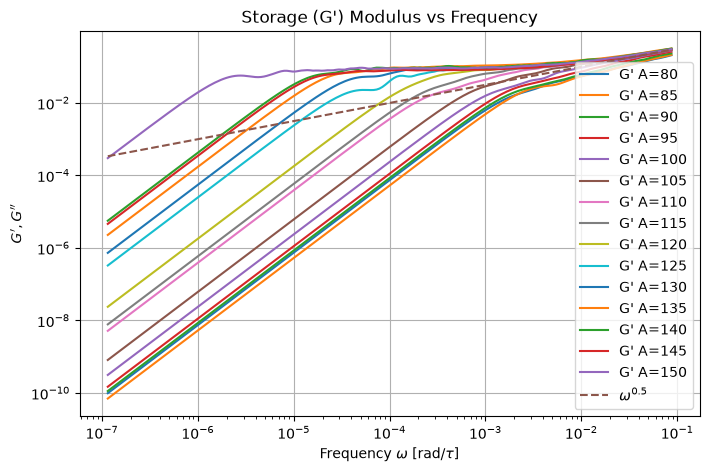

In [283]:
plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
for i, A in enumerate(As):
    plt.loglog(omega, Gp_list[i], label=f"G' A={A}")

plt.loglog(omega, omega**0.5, linestyle='--', label=r"$\omega^{0.5}$")
plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G', G''$")
# plt.xlim([1e-5, 1e-1])
# plt.ylim([1e-4, 1e0])
plt.title("Storage (G') Modulus vs Frequency")
plt.grid(True)
plt.legend()
plt.show()

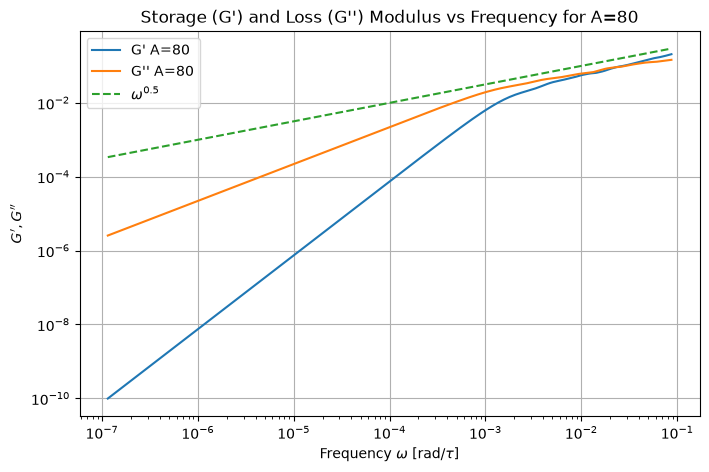

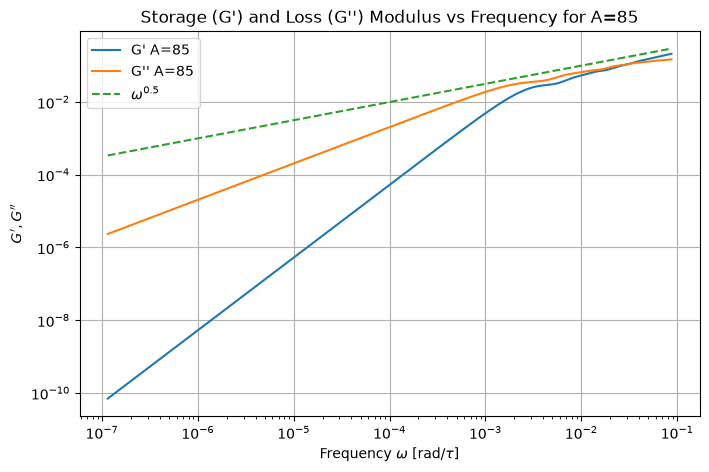

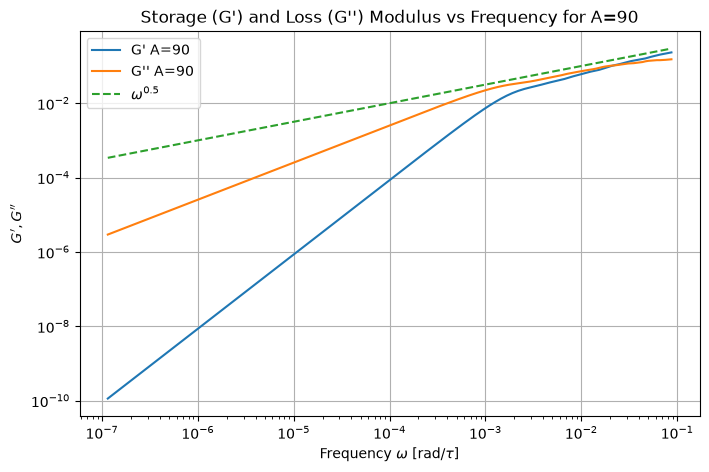

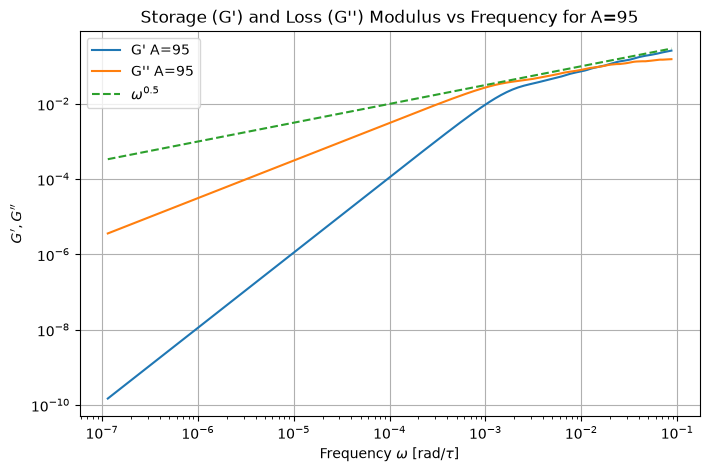

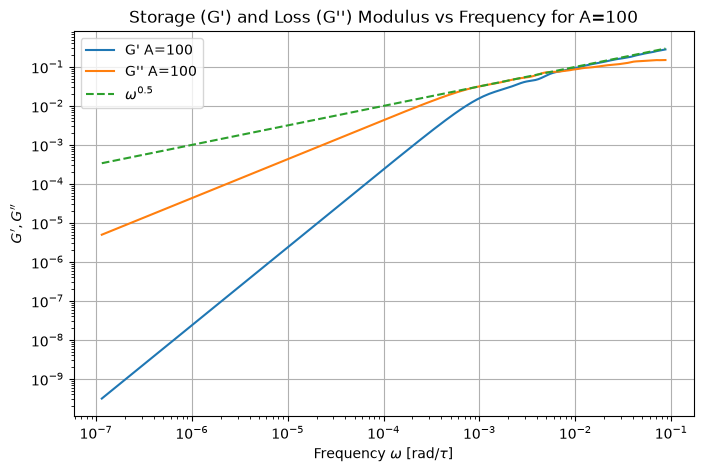

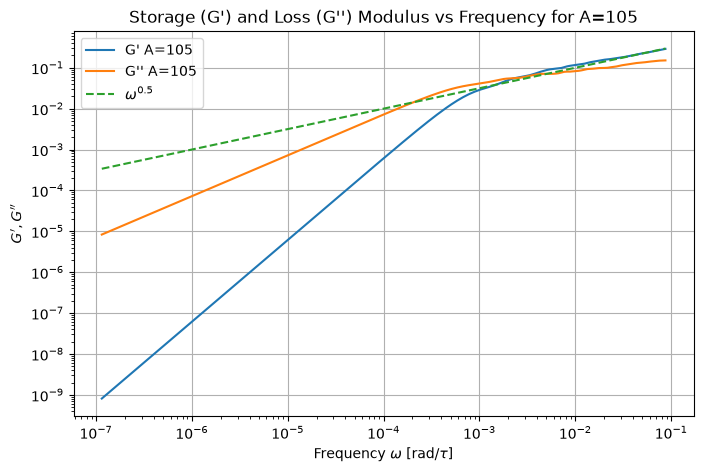

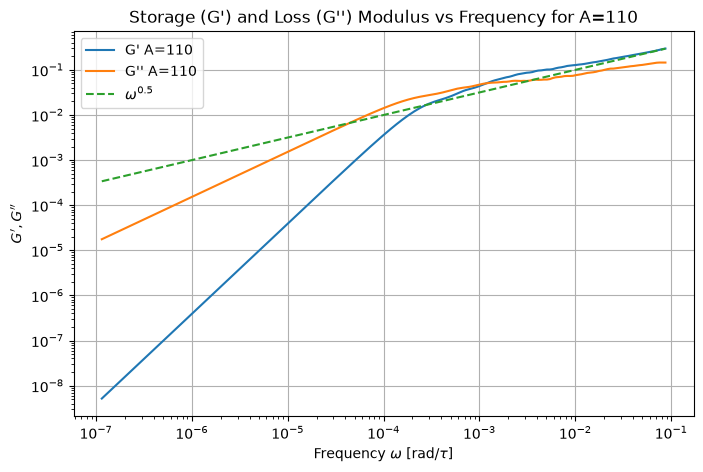

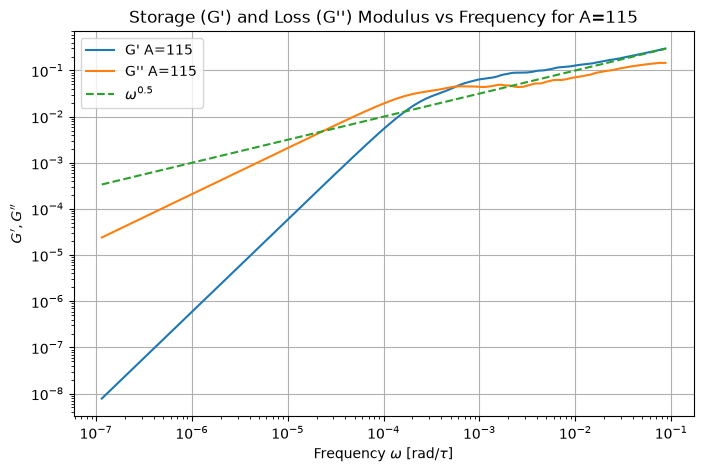

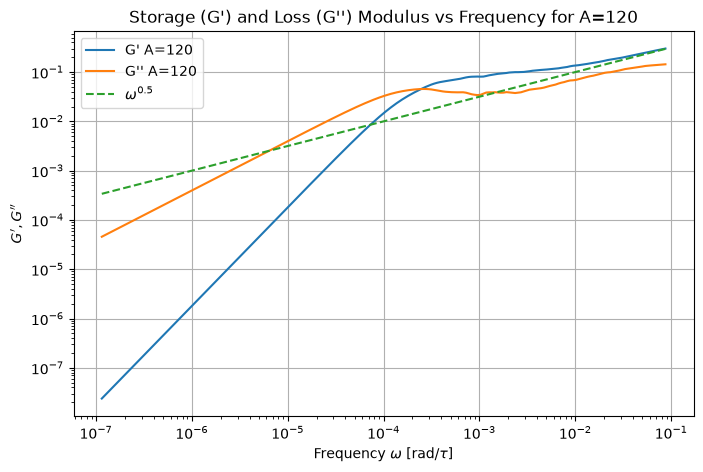

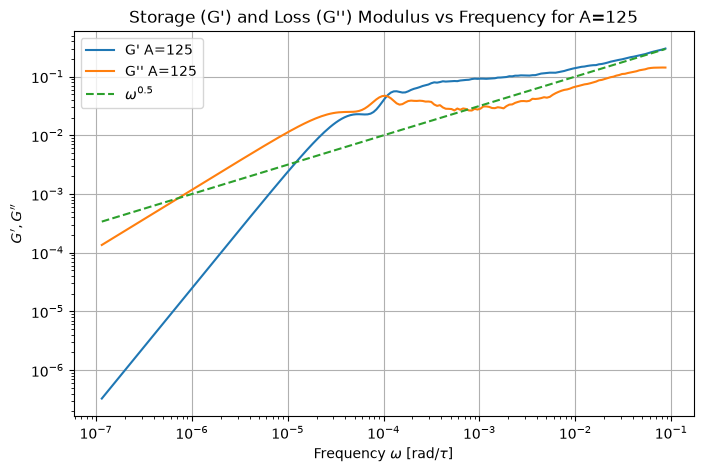

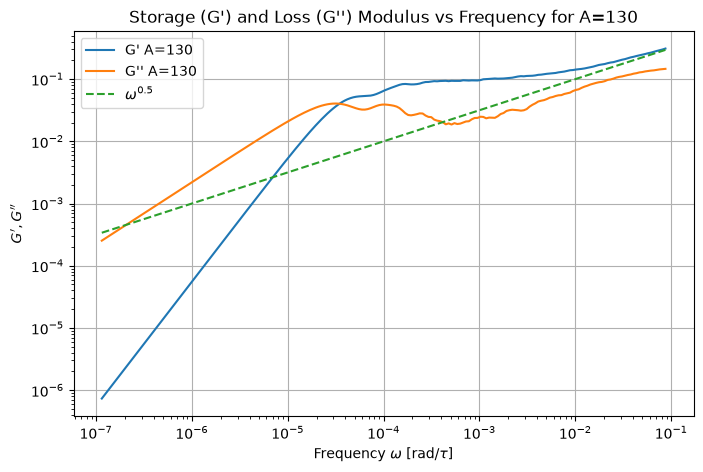

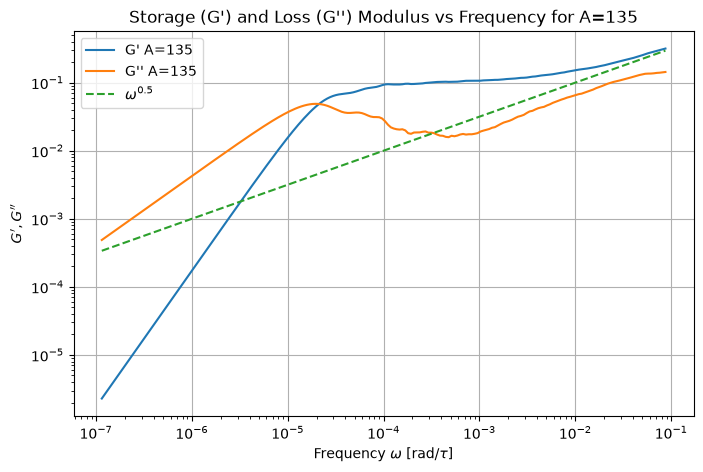

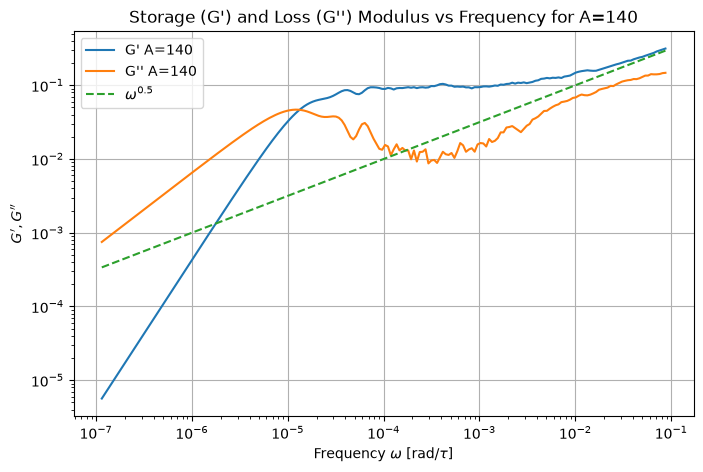

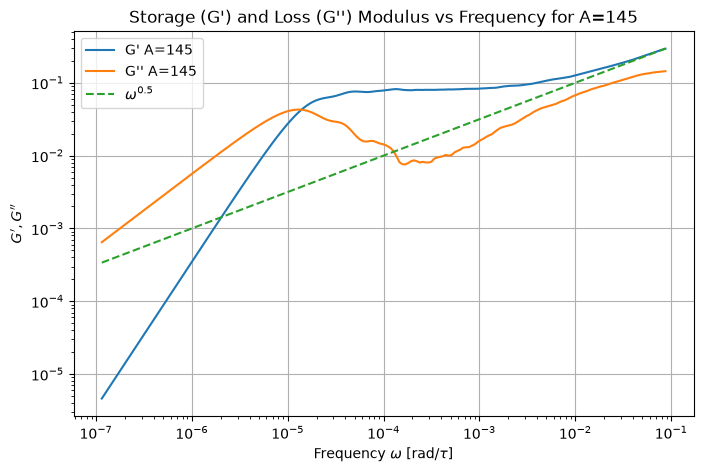

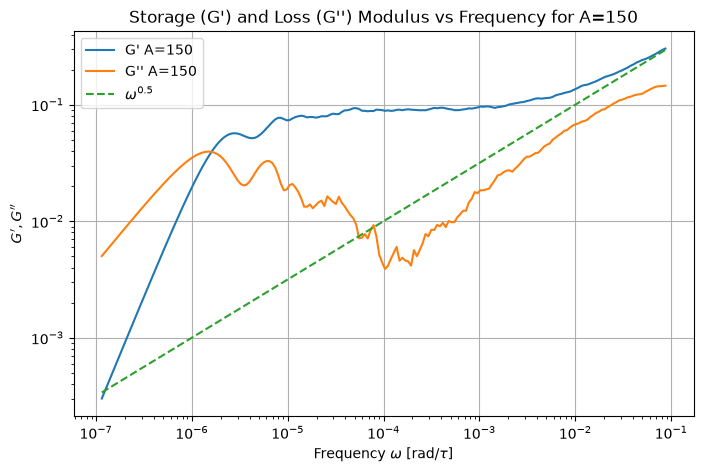

In [284]:
for i, A in enumerate(As):
    Gp = Gp_list[i]
    Gpp = Gpp_list[i]

    df = pd.DataFrame({'omega': omega, 'Gp': Gp, 'Gpp': Gpp})
    df.to_csv(f"data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.xscale('log')
    plt.yscale('log')
    plt.loglog(omega, Gp_list[i], label=f"G' A={A}")
    plt.loglog(omega, Gpp_list[i], label=f"G'' A={A}")
    plt.loglog(omega, omega**0.5, linestyle='--', label=r"$\omega^{0.5}$")
    plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
    plt.ylabel("$G', G''$")
    # plt.xlim([1e-5, 1e-1])
    # plt.ylim([1e-4, 1e0])
    plt.title(f"Storage (G') and Loss (G'') Modulus vs Frequency for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()

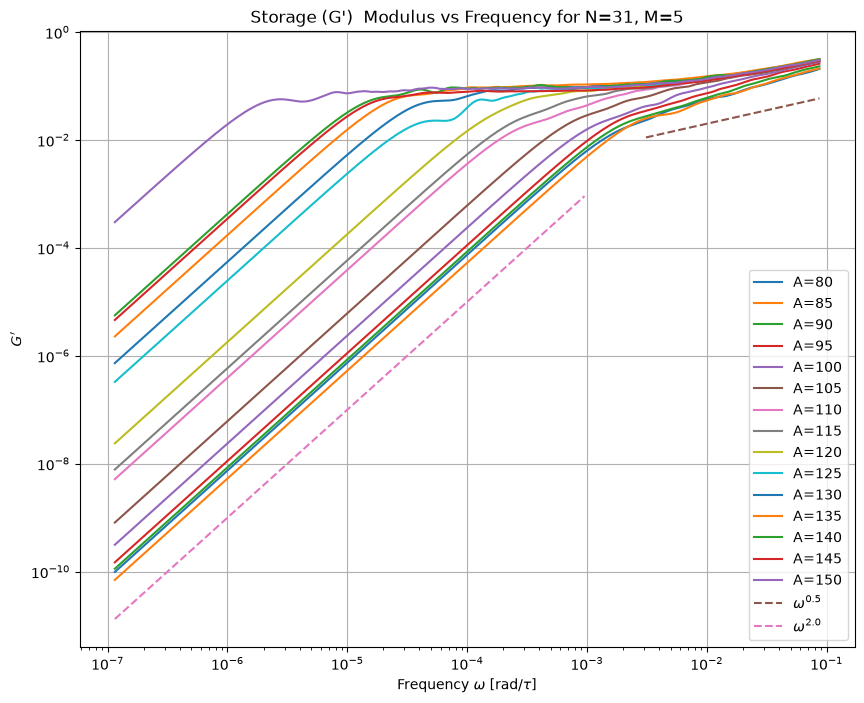

In [315]:
plt.figure(figsize=(10, 8))

for i, A in enumerate(As):
    Gp = Gp_list[i]
    Gpp = Gpp_list[i]

    df = pd.DataFrame({'omega': omega, 'Gp': Gp, 'Gpp': Gpp})
    df.to_csv(f"data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.csv", index=False)

   
    plt.loglog(omega, Gp_list[i], label=f"A={A}")
    # plt.loglog(omega, Gpp_list[i], label=f"G'' A={A}")
plt.xscale('log')
plt.yscale('log')
plt.loglog(omega[omega >= 3e-3], 0.2 * omega[omega >= 3e-3]**0.5, linestyle='--', label=r"$\omega^{0.5}$")
plt.loglog(omega[omega < 1e-3], 1000*omega[omega < 1e-3]**2.0, linestyle='--', label=r"$\omega^{2.0}$")

plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G'$")
# plt.xlim([1e-5, 1e-1])
# plt.ylim([1e-4, 1e0])
plt.title(f"Storage (G')  Modulus vs Frequency for N=31, M=5")
plt.grid(True)
plt.legend()
plt.show()

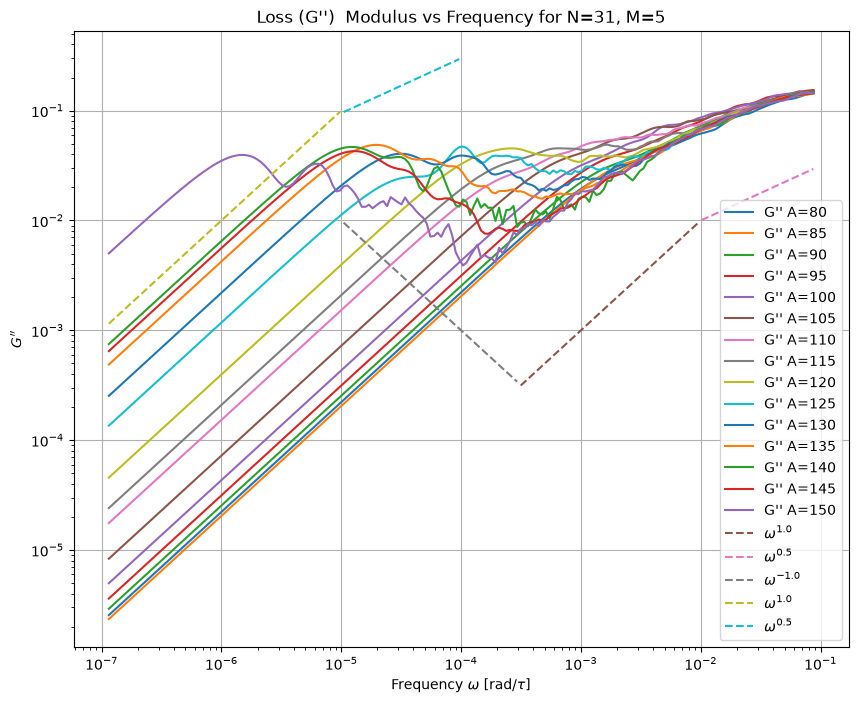

In [350]:
plt.figure(figsize=(10, 8))

for i, A in enumerate(As):
    Gp = Gp_list[i]
    Gpp = Gpp_list[i]

    df = pd.DataFrame({'omega': omega, 'Gp': Gp, 'Gpp': Gpp})
    df.to_csv(f"data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.csv", index=False)

    plt.xscale('log')
    plt.yscale('log')
    # plt.loglog(omega, Gp_list[i], label=f"G' A={A}")
    plt.loglog(omega, Gpp_list[i], label=f"G'' A={A}")
plt.loglog(omega[(omega > 3e-4) & (omega <= 1e-2)], omega[(omega > 3e-4) & (omega <= 1e-2)]**1.0, linestyle='--', label=r"$\omega^{1.0}$")
plt.loglog(omega[(omega > 1e-2) & (omega <= 1e-1)], 1e-1 * omega[(omega > 1e-2) & (omega <= 1e-1)]**0.5, linestyle='--', label=r"$\omega^{0.5}$")
plt.loglog(omega[(omega > 1e-5) & (omega <= 3e-4)], 1e-7 * omega[(omega > 1e-5) & (omega <= 3e-4)]**-1.0, linestyle='--', label=r"$\omega^{-1.0}$")
plt.loglog(omega[(omega > 1e-7) & (omega <= 1e-5)], 1e4 * omega[(omega > 1e-7) & (omega <= 1e-5)]**1.0, linestyle='--', label=r"$\omega^{1.0}$")
plt.loglog(omega[(omega > 1e-5) & (omega <= 1e-4)], 3e1 * omega[(omega > 1e-5) & (omega <= 1e-4)]**0.5, linestyle='--', label=r"$\omega^{0.5}$")



plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G''$")
# plt.xlim([1e-5, 1e-1])
# plt.ylim([1e-4, 1e0])
plt.title(f"Loss (G'')  Modulus vs Frequency for N=31, M=5")
plt.grid(True)
plt.legend()
plt.show()

In [287]:
import numpy as np

2 * np.pi/(3e-2)


209.43951023931956

## Rouse model 

In [288]:
zeta = 20
k_b = 1.72
k_B = 1
T = 1
b = np.sqrt(3 * k_B * T / k_b)
N = 31

tau_rouse = zeta * N**2 * b**2 / (3 * np.pi**2 * k_B * T)
print(f"Rouse time for N={N}: {tau_rouse:.4f} LJ time units")

Rouse time for N=31: 1132.2053 LJ time units


In [289]:
print(f"Frequency corresponding to Rouse time for N={N}: {2 * np.pi/tau_rouse:.4f} 1/LJ time units")

Frequency corresponding to Rouse time for N=31: 0.0055 1/LJ time units


In [290]:
def compute_G_t(t, tau_rouse=None, p_max=None, c=0.0274, N_b=31, k_B=1.0, T=1.0, zeta=25, b=np.sqrt(3 * 1.0 * 1.0 / 1.72)):
    if tau_rouse is None:
        tau_rouse = zeta * N_b**2 * b**2 / (3 * np.pi**2 * k_B * T)
    G_t = 0
    if p_max is None:
        p_max = N_b - 1
    for p in range(1, p_max + 1):
        G_t += np.exp(-3 * t * p**2 / tau_rouse)
    G_t *=c * k_B * T
    return G_t


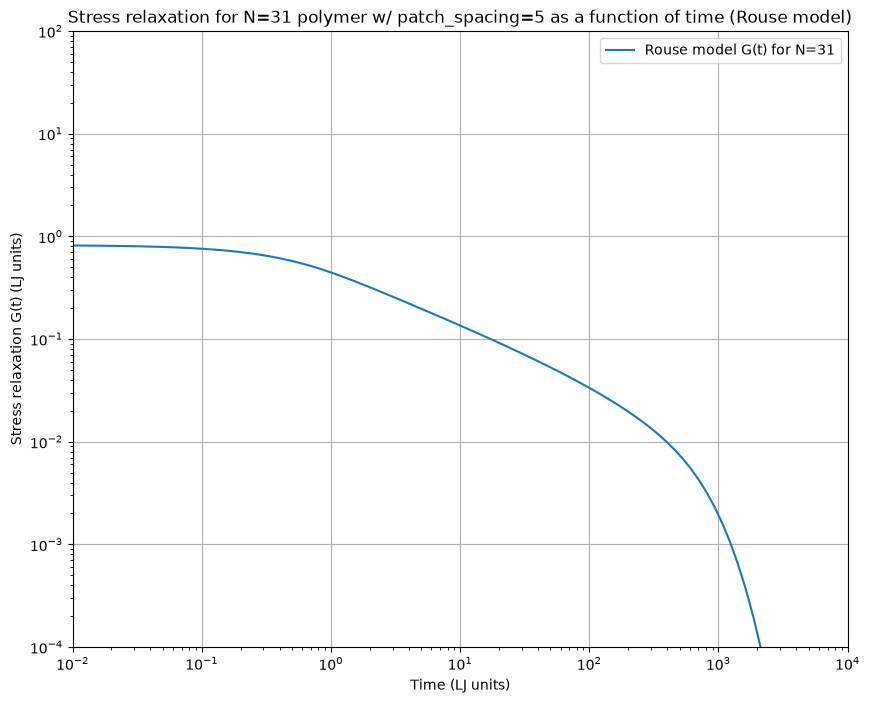

In [291]:
t = np.logspace(-2, 4, 100)
G_t = compute_G_t(t, tau_rouse, p_max=30)

fig = plt.figure(figsize=(10, 8))
plt.xscale('log')
plt.yscale('log')
plt.loglog(t, G_t, label='Rouse model G(t) for N=31')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e4])
plt.ylim([1e-4, 1e2])
plt.grid()
plt.title('Stress relaxation for N=31 polymer w/ patch_spacing=5 as a function of time (Rouse model)')
plt.legend()
plt.show()

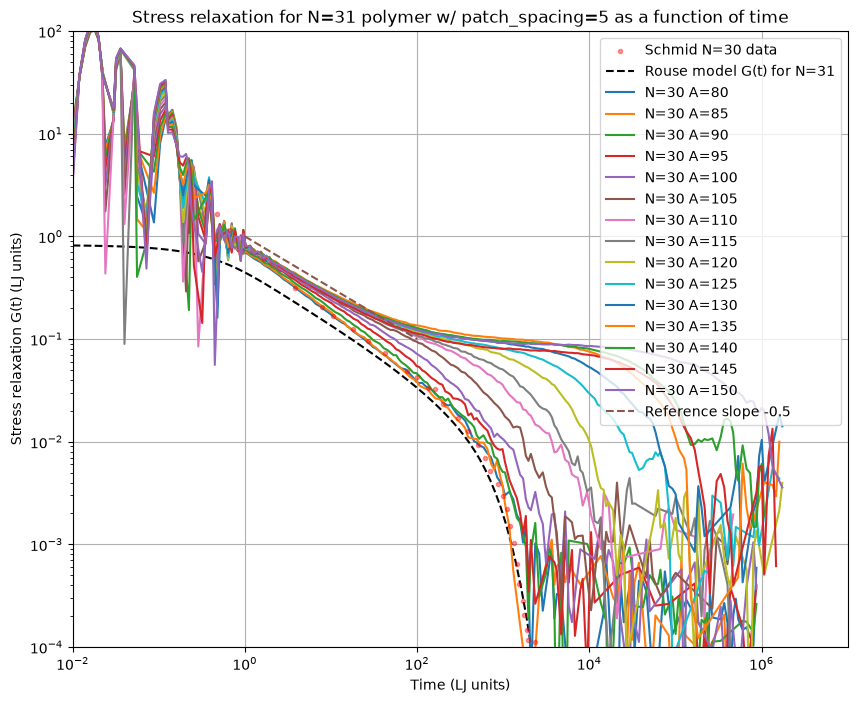

In [292]:
plt.figure(figsize=(10, 8))
plt.xscale('log')
plt.yscale('log')

# plt.loglog(data_multitau['time'], G_t_multitau , label='multitau autocorrelation')
# plt.loglog(data_multitau_no_langevin['time'], G_t_multitau_no_langevin , label='multitau autocorrelation (no Langevin)')
plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)

plt.loglog(t, G_t, label='Rouse model G(t) for N=31', linestyle='--', color='black')

for i, A in enumerate(As):
    plt.loglog(data[i]['time'], data[i]['G_t'], label=f'N=30 A={A}')

plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e7])
plt.ylim([1e-4,1e2])
plt.grid()
plt.title('Stress relaxation for N=31 polymer w/ patch_spacing=5 as a function of time')
plt.legend()
plt.show()

In [293]:
rouse_Gp, rouse_Gpp = process_dyn_moduli(pd.DataFrame({'time': t, 'G_t': G_t}), omega=omega, cutoff=2000)

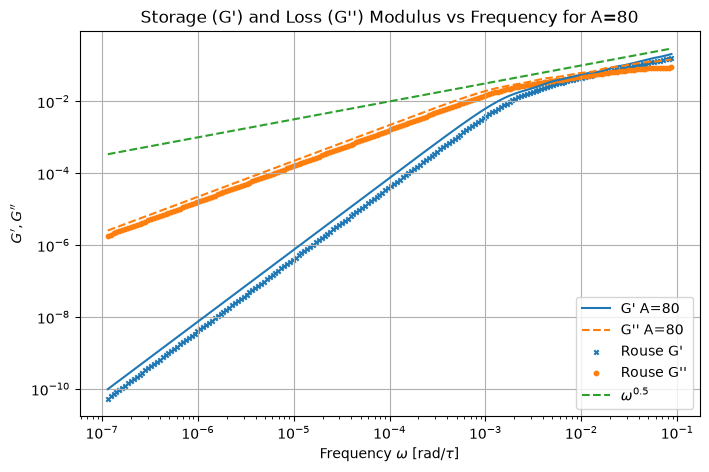

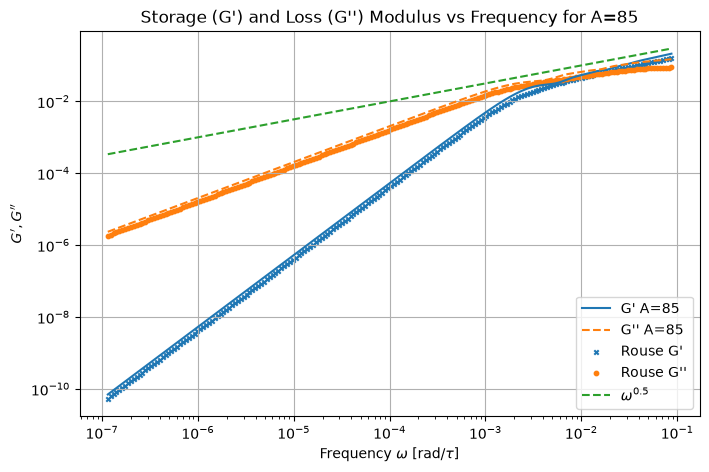

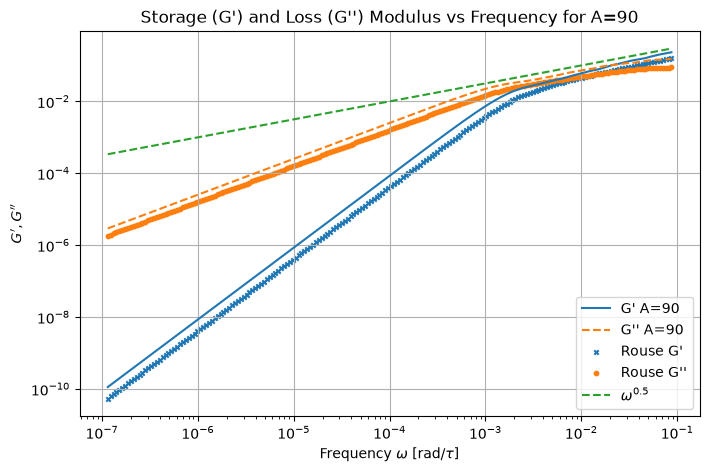

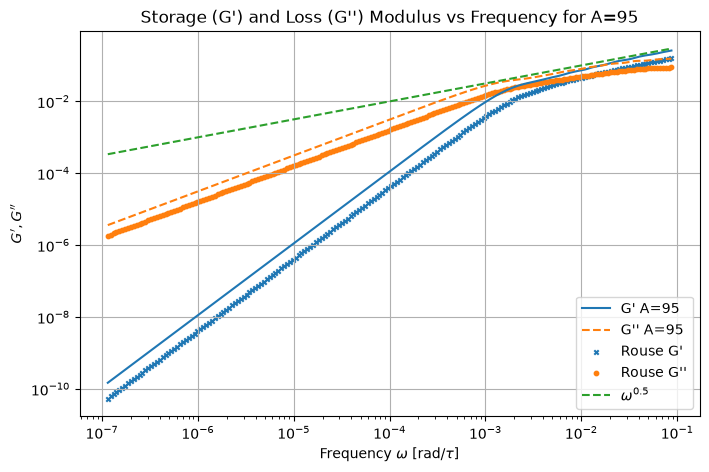

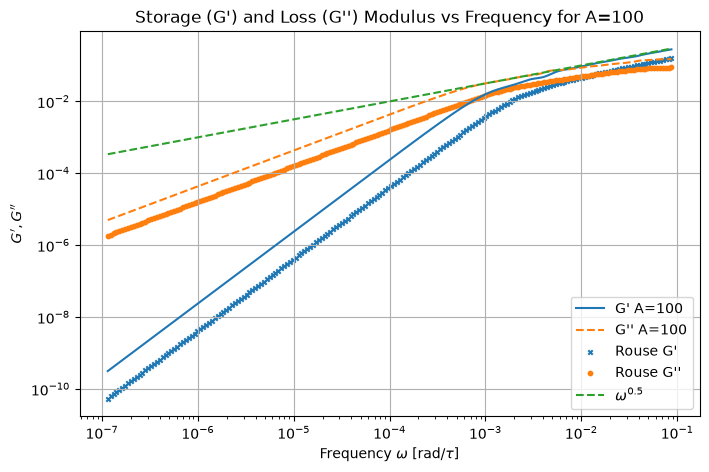

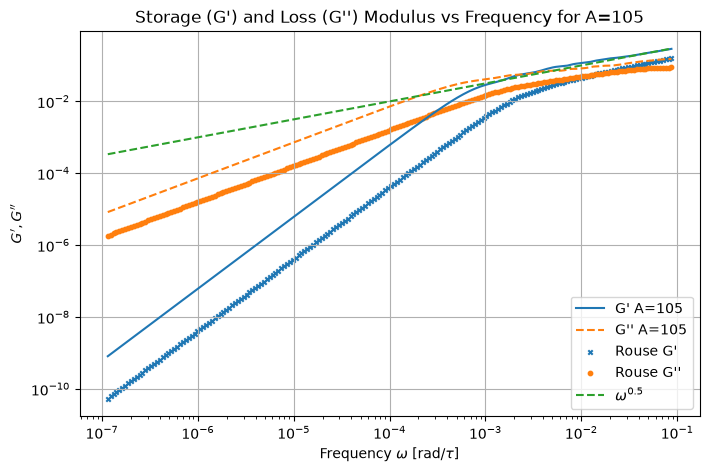

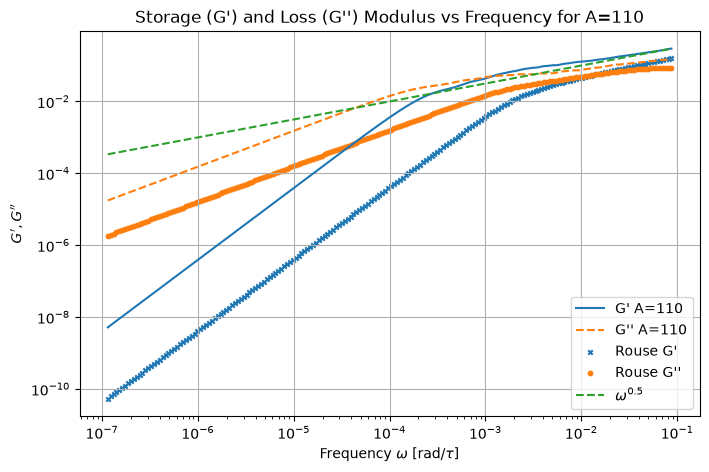

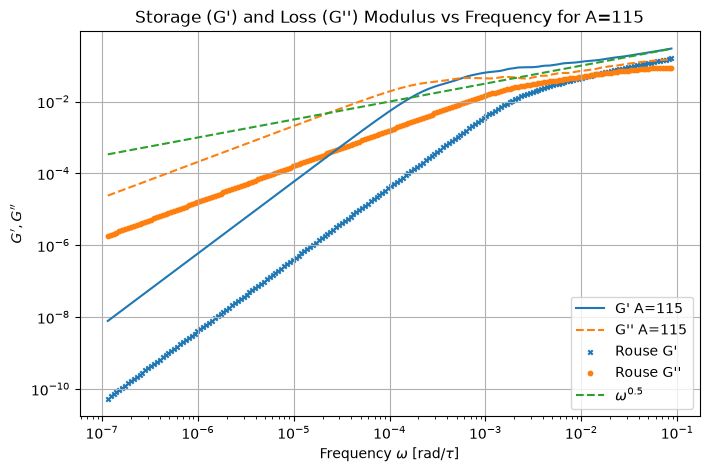

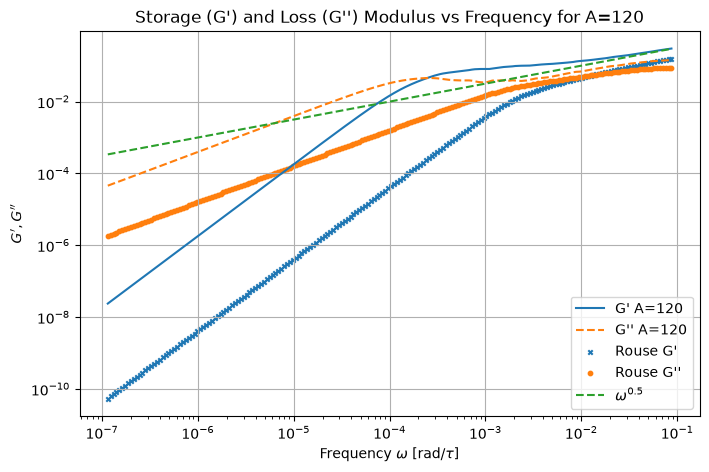

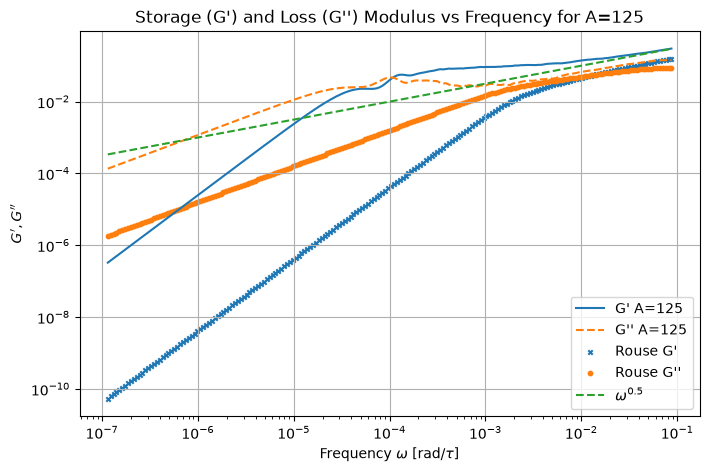

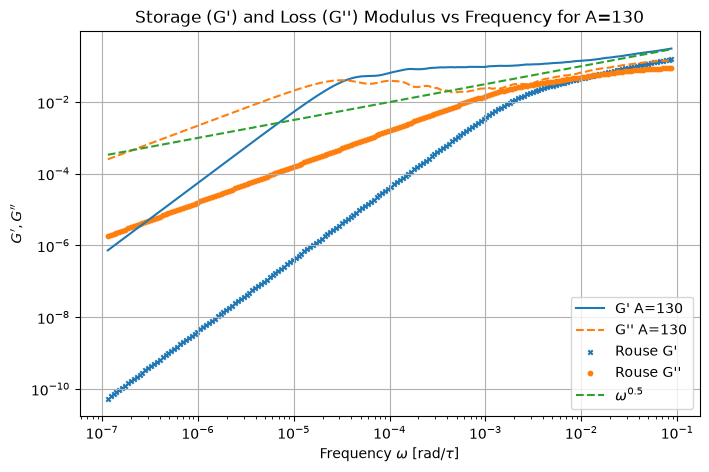

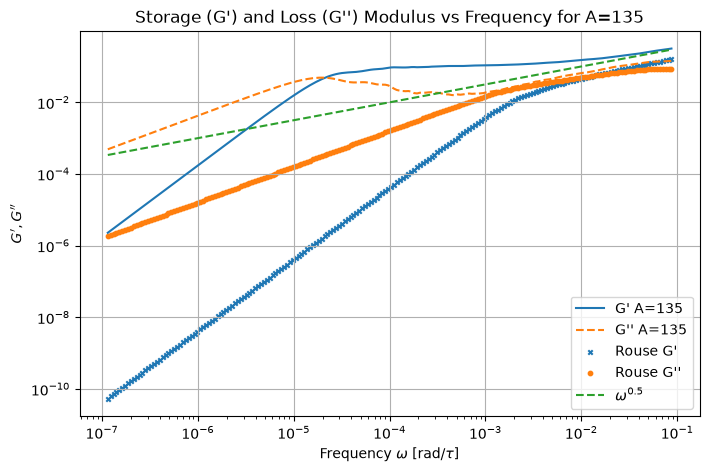

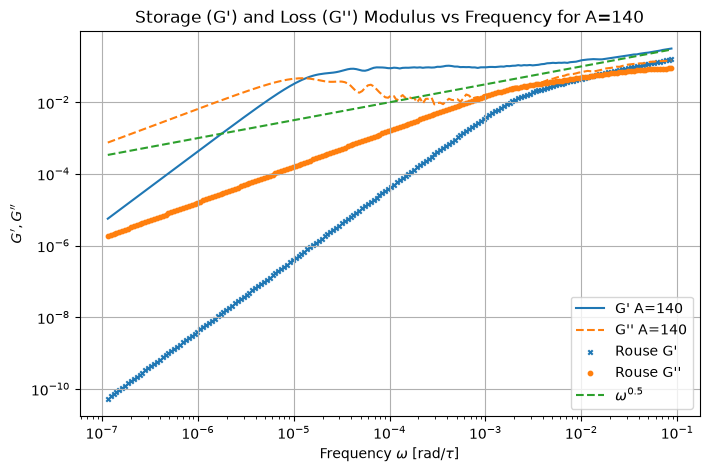

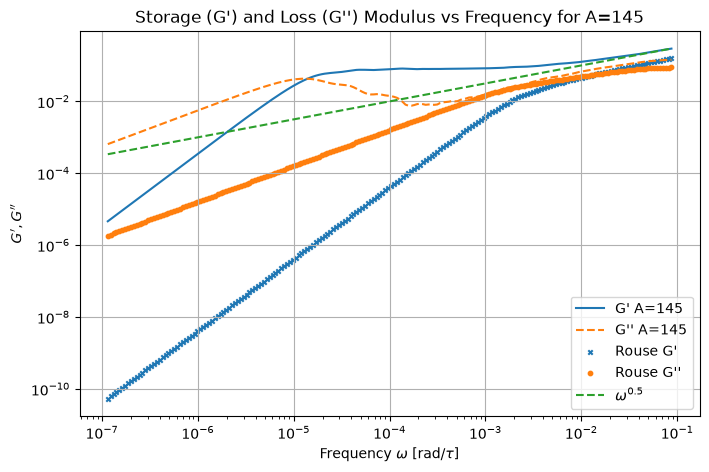

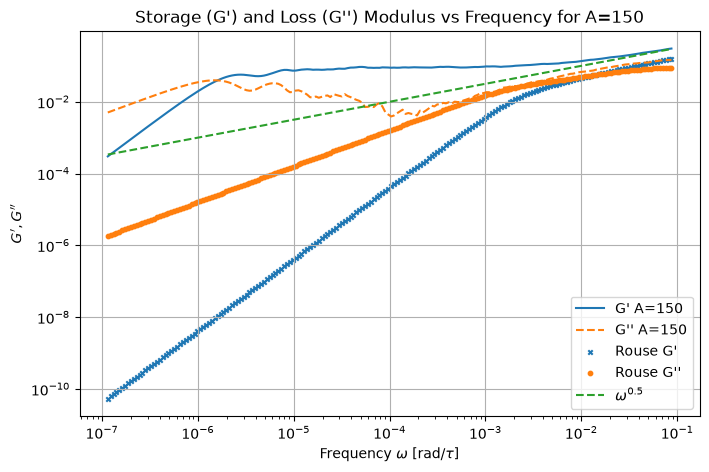

In [294]:
for i, A in enumerate(As):
    Gp = Gp_list[i]
    Gpp = Gpp_list[i]

    df = pd.DataFrame({'omega': omega, 'Gp': Gp, 'Gpp': Gpp})
    df.to_csv(f"data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.xscale('log')
    plt.yscale('log')
    plt.loglog(omega, Gp_list[i], label=f"G' A={A}")
    plt.loglog(omega, Gpp_list[i], linestyle='--',label=f"G'' A={A}")
    plt.scatter(omega, rouse_Gp, marker='x', s=10, label="Rouse G'")
    plt.scatter(omega, rouse_Gpp, marker='o', s=10, label="Rouse G''")
    plt.loglog(omega, omega**0.5, linestyle='--', label=r"$\omega^{0.5}$")
    plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
    plt.ylabel("$G', G''$")
    # plt.xlim([1e-5, 1e-1])
    # plt.ylim([1e-4, 1e0])
    plt.title(f"Storage (G') and Loss (G'') Modulus vs Frequency for A={A}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [295]:
# get rouse_Gp, rouse_Gpp with fourier transform of G(t) terms

p = np.arange(1, 10000 + 1)
tau_p = tau_rouse / (p**2)
G_p = c * k_B * T

rouse_Gp = np.zeros_like(omega)
rouse_Gpp = np.zeros_like(omega)

for i, ome in enumerate(omega):
    rouse_Gp[i] = np.sum(G_p * (ome * tau_p) / (1 + (ome * tau_p)**2))
    rouse_Gpp[i] = np.sum(G_p / (1 + (ome * tau_p)**2))
print(rouse_Gp, rouse_Gpp)

fig = plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
# for i, A in enumerate(As):
#     plt.loglog(omega, Gp_list[i], label=f"G' A={A}")
#     plt.loglog(omega, Gpp_list[i], linestyle='--',label=f"G'' A={A}")
plt.scatter(freq, rouse_Gp, marker='x', s=10, label="Rouse G'")
plt.scatter(freq, rouse_Gpp, marker='o', s=10, label="Rouse G''")
plt.loglog(omega, omega**0.5, linestyle='--', label=r"$\omega^{0.5}$")
plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G', G''$")
plt.title(f"Storage (G') and Loss (G'') Modulus vs Frequency for N=31 polymer w/ patch_spacing=5")
plt.grid(True)
plt.legend()
# plt.xlim([1e-5, 1e5])
# plt.ylim([1e-4, 1e2])
plt.show()

NameError: name 'c' is not defined

In [ ]:
rouse_Gp, rouse_Gpp = process_dyn_moduli(pd.DataFrame({'time': t, 'G_t': G_t}), omega=omega, cutoff=2000)

## Fit $\zeta$ for Rouse data



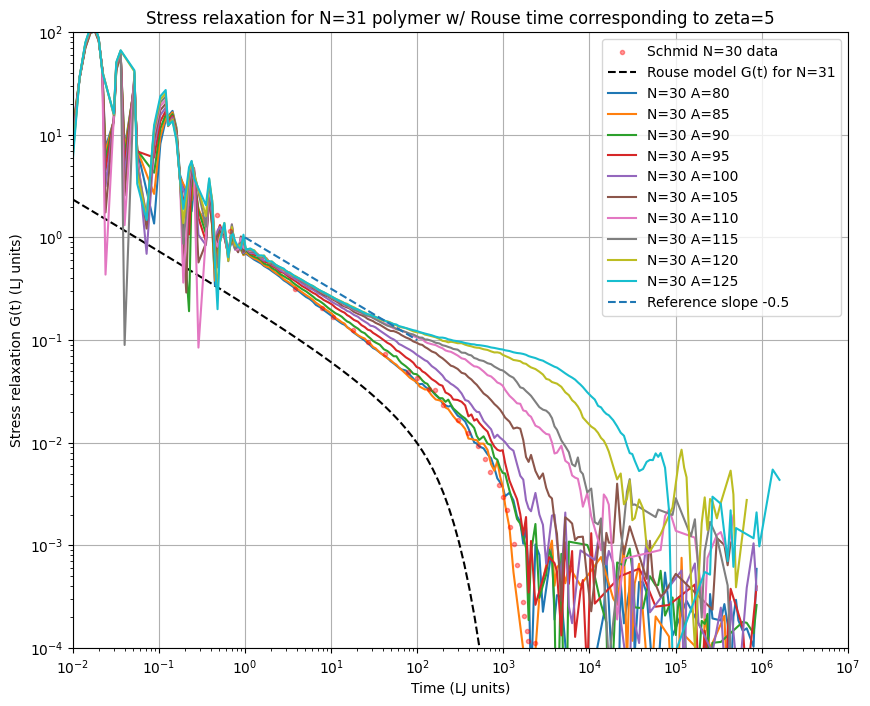

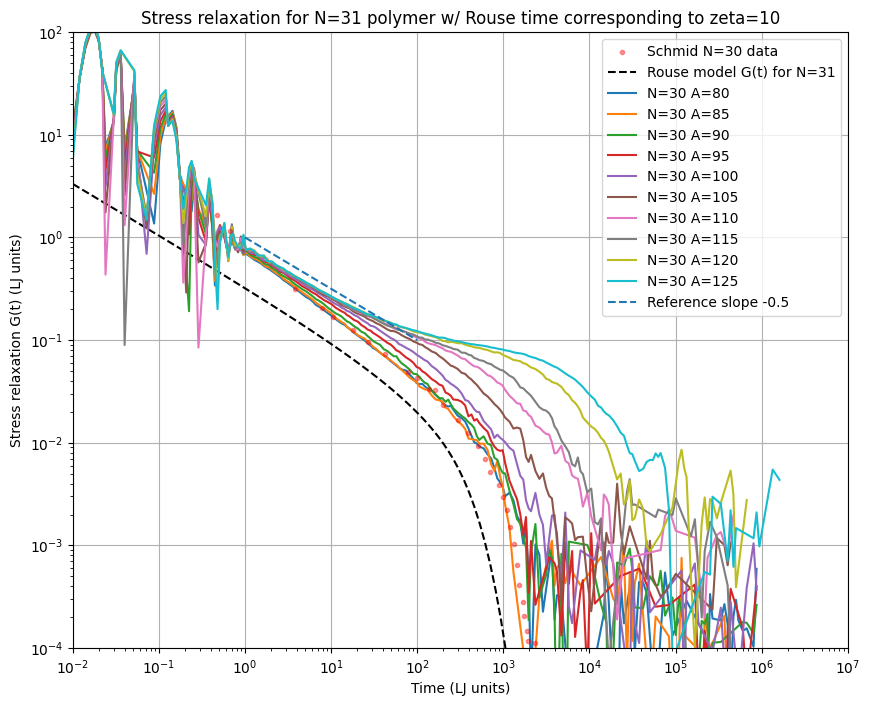

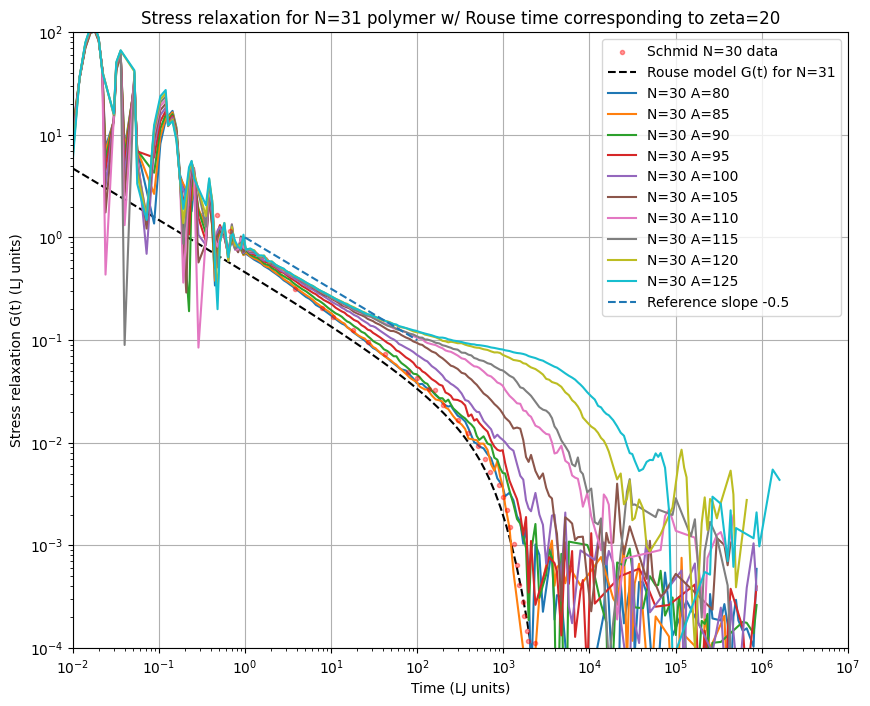

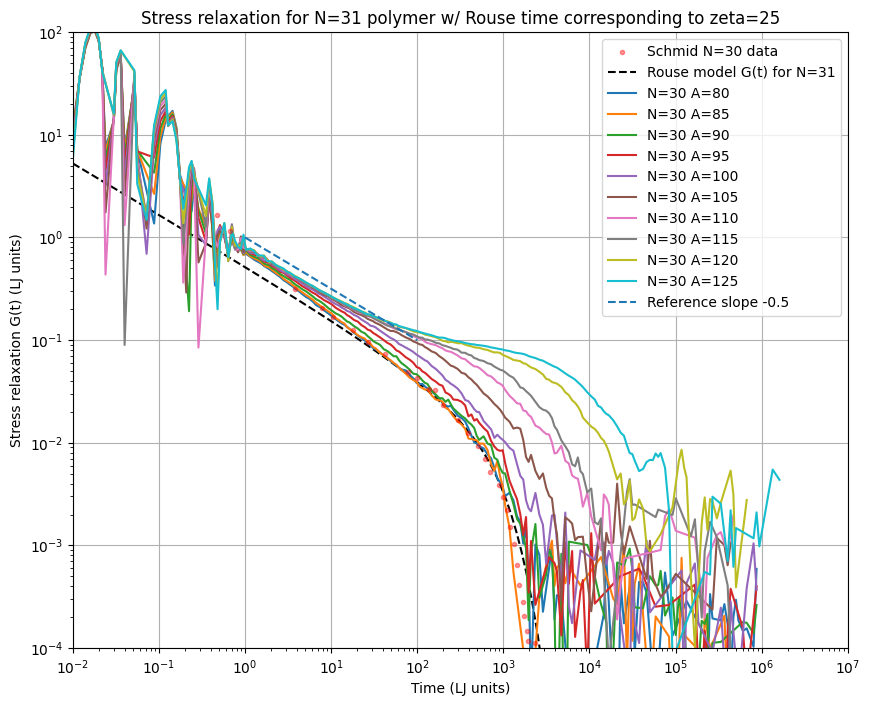

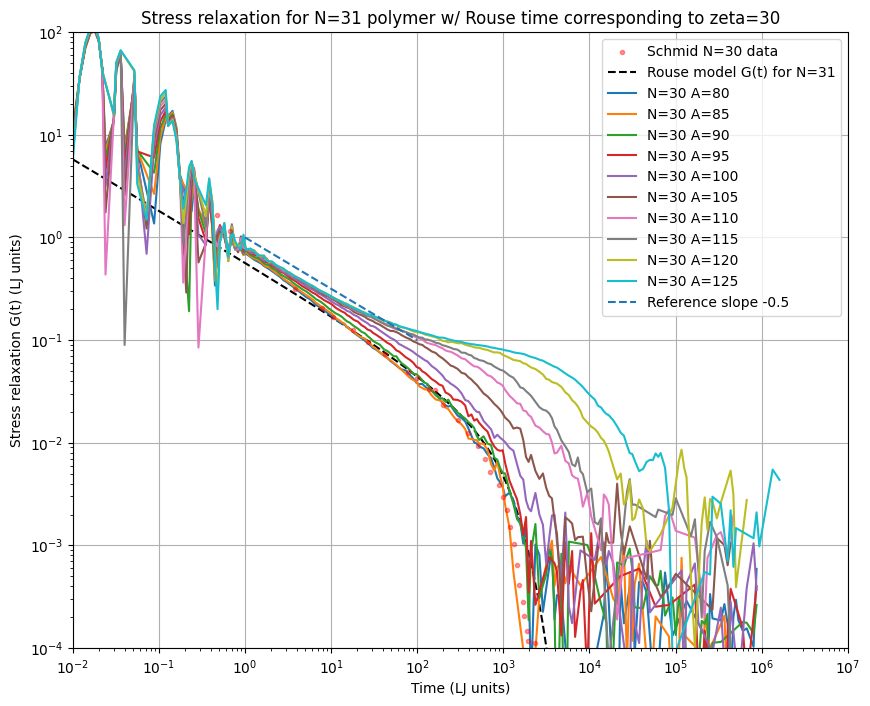

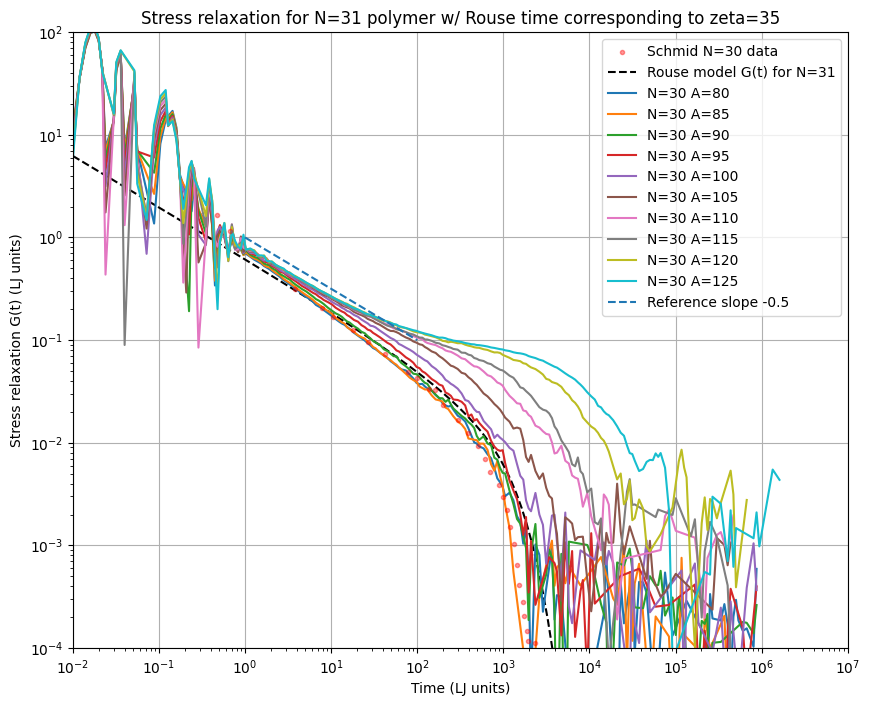

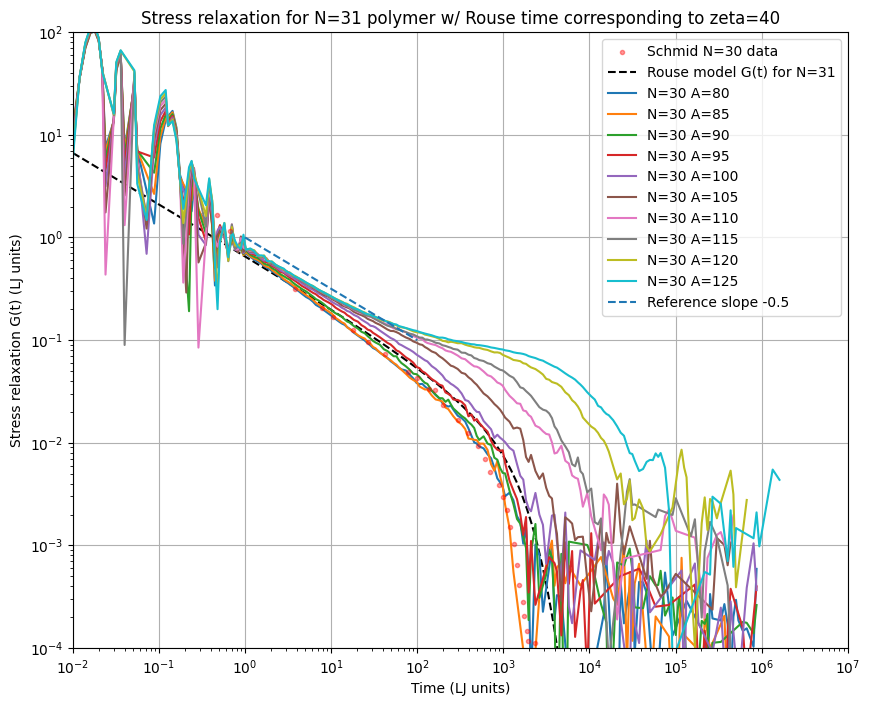

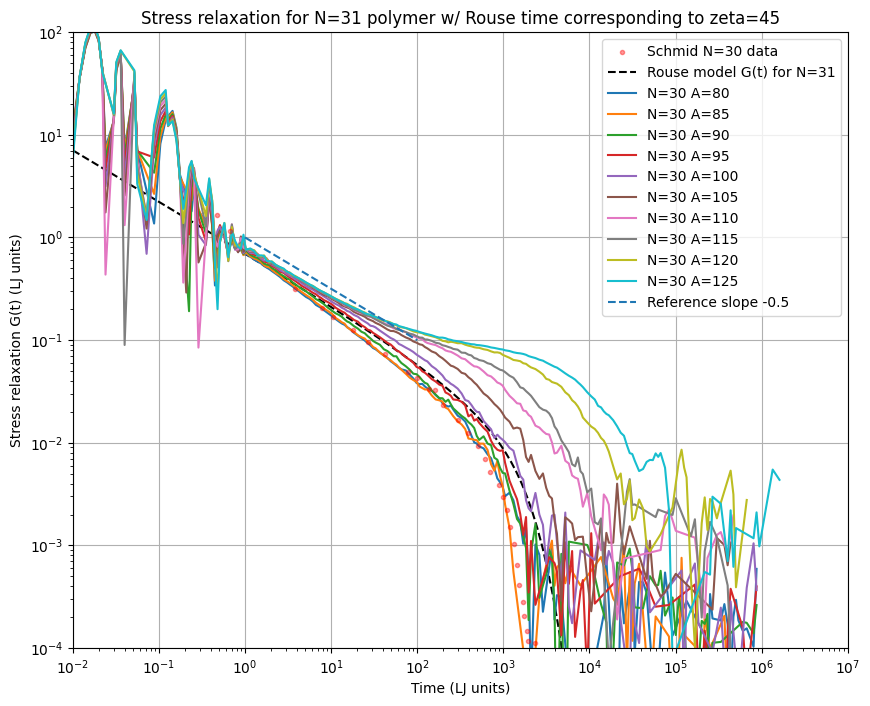

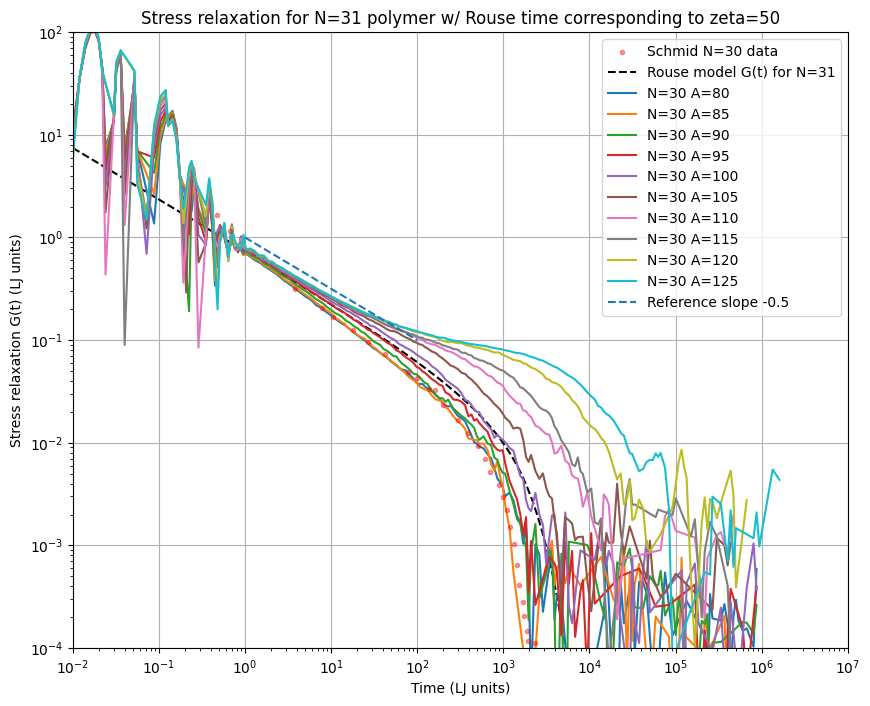

In [ ]:
t = np.logspace(-2, 4, 100)


for zeta in [5, 10, 20, 25, 30, 35, 40, 45, 50]:
    G_t = compute_G_t(t, tau_rouse=None, p_max=100000, zeta=zeta)
    plt.figure(figsize=(10, 8))
    plt.xscale('log')
    plt.yscale('log')

    # plt.loglog(data_multitau['time'], G_t_multitau , label='multitau autocorrelation')
    # plt.loglog(data_multitau_no_langevin['time'], G_t_multitau_no_langevin , label='multitau autocorrelation (no Langevin)')
    plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)

    plt.loglog(t, G_t, label='Rouse model G(t) for N=31', linestyle='--', color='black')

    for i, A in enumerate(As):
        plt.loglog(data[i]['time'], data[i]['G_t'], label=f'N=30 A={A}')

    plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
    plt.xlabel('Time (LJ units)')
    plt.ylabel('Stress relaxation G(t) (LJ units)')
    plt.xlim([1e-2, 1e7])
    plt.ylim([1e-4,1e2])
    plt.grid()
    plt.title(f'Stress relaxation for N=31 polymer w/ Rouse time corresponding to zeta={zeta}')
    plt.legend()
    plt.show()